# Utilizar método de Schnorr para factorizar N buscando pares pn-smooth con Cuántica

Este notebook va a ser una primera aproximación para explicar el procedimiento utilizado por Schnorr en sus papers:
- [Schnorr factoring via Diophantine Approximation](https://link.springer.com/chapter/10.1007/3-540-46416-6_24#preview).
- [Schnorr fast factoring by SVP, corrected](https://eprint.iacr.org/2021/933.pdf)
- [Yan et al.](https://arxiv.org/pdf/2212.12372)
- [BenBen Priestley](https://arxiv.org/abs/2503.08403)
- [L.S.Cano, G.B.Juan, G.C. de las Heras, A.B. García. "Factoring integers via Schnorr' algorithm assisted with VQE"](https://arxiv.org/abs/2411.16632)

### 0. Estructura del TFG.
- Título: Simulación de algoritmos variacionales cuántico-clásicos (QAOA y VQE) aplicados a problemas de retículos (CVP y SVP).
- Objetivo: comparar dos enfoques cuántico-clásicos ejecutables en CPU.
- Parte 1: CVP con QAOA de ángulos fijos en Python (BenPrie/qaoa-for-cvp).
- Parte 2: SVP con VQE/QAOA simulados mediante LattiQ en C++ (Milos9304/LattiQ).

Ambos transforman el problema en un modelo Ising/QUBO.
- Introducción: relevancia de CVP y SVP en criptografía post-cuántica.
- Marco teórico: bases de QAOA, VQE y formulaciones Ising.
- Implementación: descripción, parámetros y ejecución en CPU.
- Resultados: comparación de energía, tiempo y precisión.
- Discusión: QAOA fijo → rápido pero aproximado; LattiQ → más exacto pero lento.
- Conclusiones: ambos son viables, educativos y reproducibles sin QPU.
- Trabajo futuro: añadir ruido, escalar qubits y explorar otras formulaciones.

In [1]:
# Realizo los imports
import numpy as np
from fpylll import IntegerMatrix, LLL, GSO
from copy import deepcopy
import sympy
from scipy.optimize import minimize


# Time keeping.
import time

# Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

Aqui establecemos una pequeña lista de los primeros numeros primos

In [2]:
primes = [2,3,5,7,11,13,17,19,23,29,31,37,41,43,47,53,59,61,67,71,73,79,83,89,97,101,103,107,109,113,127,131,137,139,149,151,157,163,167,173,179,181,191,193,197,199,211,223,227,229,233,239,241,251,257,263,269,271,277,281,283,293,307,311,313,317,331,337,347,349,353,359,367,373,379,383,389,397,401,409,419,421,431,433,439,443,449,457,461,463,467,479,487,491,499,503,509,521,523,541,547,557,563,569,571,577,587,593,599,601,607,613,617,619,631,641,643,647,653,659,661,673,677,683,691,701,709,719,727,733,739,743,751,757,761,769,773,787,797,809,811,821,823,827,829,839,853,857,859,863,877,881,883,887,907,911,919,929,937,941,947,953,967,971,977,983,991,997,1009,1013,1019,1021,1031,1033,1039,1049,1051,1061,1063,1069,1087,1091,1093,1097,1103,1109,1117,1123,1129,1151,1153,1163,1171,1181,1187,1193,1201,1213,1217,1223,1229,1231,1237,1249,1259,1277,1279,1283,1289,1291,1297,1301,1303,1307,1319,1321,1327,1361,1367,1373,1381,1399,1409,1423,1427,1429,1433,1439,1447,1451,1453,1459,1471,1481,1483,1487,1489,1493,1499,1511,1523,1531,1543,1549,1553,1559,1567,1571,1579,1583,1597,1601,1607,1609,1613,1619,1621,1627,1637,1657,1663,1667,1669,1693,1697,1699,1709,1721,1723,1733,1741,1747,1753,1759,1777,1783,1787,1789,1801,1811,1823,1831,1847,1861,1867,1871,1873,1877,1879,1889,1901,1907,1913,1931,1933,1949,1951,1973,1979,1987,1993,1997,1999,2003,2011,2017,2027,2029,2039,2053,2063,2069,2081,2083,2087,2089,2099,2111,2113,2129,2131,2137,2141,2143,2153,2161,2179,2203,2207,2213,2221,2237,2239,2243,2251,2267,2269,2273,2281,2287,2293,2297,2309,2311,2333,2339,2341,2347,2351,2357,2371,2377,2381,2383,2389,2393,2399,2411,2417,2423,2437,2441,2447,2459,2467,2473,2477,2503,2521,2531,2539,2543,2549,2551,2557,2579,2591,2593,2609,2617,2621,2633,2647,2657,2659,2663,2671,2677,2683,2687,2689,2693,2699,2707,2711,2713,2719,2729,2731,2741,2749,2753,2767,2777,2789,2791,2797,2801,2803,2819,2833,2837,2843,2851,2857,2861,2879,2887,2897,2903,2909,2917,2927,2939,2953,2957,2963,2969,2971,2999,3001,3011,3019,3023,3037,3041,3049,3061,3067,3079,3083,3089,3109,3119,3121,3137,3163,3167,3169,3181,3187,3191,3203,3209,3217,3221,3229,3251,3253,3257,3259,3271,3299,3301,3307,3313,3319,3323,3329,3331,3343,3347,3359,3361,3371,3373,3389,3391,3407,3413,3433,3449,3457,3461,3463,3467,3469,3491,3499,3511,3517,3527,3529,3533,3539,3541,3547,3557,3559,3571,3581,3583,3593,3607,3613,3617,3623,3631,3637,3643,3659,3671,3673,3677,3691,3697,3701,3709,3719,3727,3733,3739,3761,3767,3769,3779,3793,3797,3803,3821,3823,3833,3847,3851,3853,3863,3877,3881,3889,3907,3911,3917,3919,3923,3929,3931,3943,3947,3967,3989,4001,4003,4007,4013,4019,4021,4027,4049,4051,4057,4073,4079,4091,4093,4099,4111,4127,4129,4133,4139,4153,4157,4159,4177,4201,4211,4217,4219,4229,4231,4241,4243,4253,4259,4261,4271,4273,4283,4289,4297,4327,4337,4339,4349,4357,4363,4373,4391,4397,4409,4421,4423,4441,4447,4451,4457,4463,4481,4483,4493,4507,4513,4517,4519,4523,4547,4549,4561,4567,4583,4591,4597,4603,4621,4637,4639,4643,4649,4651,4657,4663,4673,4679,4691,4703,4721,4723,4729,4733,4751,4759,4783,4787,4789,4793,4799,4801,4813,4817,4831,4861,4871,4877,4889,4903,4909,4919,4931,4933,4937,4943,4951,4957,4967,4969,4973,4987,4993,4999,5003,5009,5011,5021,5023,5039,5051,5059,5077,5081,5087,5099,5101,5107,5113,5119,5147,5153,5167,5171,5179,5189,5197,5209,5227,5231,5233,5237,5261,5273,5279,5281,5297,5303,5309,5323,5333,5347,5351,5381,5387,5393,5399,5407,5413,5417,5419,5431,5437,5441,5443,5449,5471,5477,5479,5483,5501,5503,5507,5519,5521,5527,5531,5557,5563,5569,5573,5581,5591,5623,5639,5641,5647,5651,5653,5657,5659,5669,5683,5689,5693,5701,5711,5717,5737,5741,5743,5749,5779,5783,5791,5801,5807,5813,5821,5827,5839,5843,5849,5851,5857,5861,5867,5869,5879,5881,5897,5903,5923,5927,5939,5953,5981,5987,6007,6011,6029,6037,6043,6047,6053,6067,6073,6079,6089,6091,6101,6113,6121,6131,6133,6143,6151,6163,6173,6197,6199,6203,6211,6217,6221,6229,6247,6257,6263,6269,6271,6277,6287,6299,6301,6311,6317,6323,6329,6337,6343,6353,6359,6361,6367,6373,6379,6389,6397,6421,6427,6449,6451,6469,6473,6481,6491,6521,6529,6547,6551,6553,6563,6569,6571,6577,6581,6599,6607,6619,6637,6653,6659,6661,6673,6679,6689,6691,6701,6703,6709,6719,6733,6737,6761,6763,6779,6781,6791,6793,6803,6823,6827,6829,6833,6841,6857,6863,6869,6871,6883,6899,6907,6911,6917,6947,6949,6959,6961,6967,6971,6977,6983,6991,6997,7001,7013,7019,7027,7039,7043,7057,7069,7079,7103,7109,7121,7127,7129,7151,7159,7177,7187,7193,7207,7211,7213,7219,7229,7237,7243,7247,7253,7283,7297,7307,7309,7321,7331,7333,7349,7351,7369,7393,7411,7417,7433,7451,7457,7459,7477,7481,7487,7489,7499,7507,7517,7523,7529,7537,7541,7547,7549,7559,7561,7573,7577,7583,7589,7591,7603,7607,7621,7639,7643,7649,7669,7673,7681,7687,7691,7699,7703,7717,7723,7727,7741,7753,7757,7759,7789,7793,7817,7823,7829,7841,7853,7867,7873,7877,7879,7883,7901,7907,7919]

## 1. Algoritmo de Schnorr

Schnorr propuso un algoritmo para resolver la factorización de enteros en el problema de retículos "Lattices" CVP. Lo que busca son los denominados pares de enteros "suaves" o pares sr (smooth relation pairs).

**Definicion 1.**\
Llamamos $P_n$ = $\{p_i\}_{i = 0,...,n}$ la n-ésima base de primos donde cada $p_i$ representa el i-ésimo primo para $i>0$ y donde $p_0 = -1$ para representar enteros negativos.  


**Definicion 2**\
Un entero N es llamado $p_n$-smooth o $p_n$-suave si todos sus factores primos están en $P_n$, i.e, si $\forall p$ primo tal que $p|N$ se cumple que $p \in P_n$.

**Definicion 3**
Sean $u,v \in \mathbb{Z}$ se dice que el par (u,v) es un par $p_n-smooth$ si $u$ y $v$ son $p_n-smooth$.\
También llamamos a $(u,v)$ un par sr o smooth relation pair si:

$$u = \prod_{i = 1}^{n}{p_i^{e_i}}$$
$$u - vN = \prod_{i = 0}^{n}{p_i^{e'_i}}$$

Es decir, que $u - vN$ también sea $p_n-smooth$ y $N$  es el entero a factorizar.


Entonces dado $(u,v)$ un par sr tenemos lo siguiente:
$$\frac{u - vN}{u} \equiv \prod_{i = 0}^{n}{p_i^{e'_i - e_i}} \equiv 1 \mod N$$
ya que $u - vN \equiv u \mod N$.

Si conseguimos encontrar $n + 1$ pares sr "suficientemente" pequeños $(u_j, v_j)$ y tomando sus exponentes obtenemos un sistema de ecuaciones con solución para $t_1,t_2,..,t_{n + 1}$:
$$\sum_{j = 1}^{n + 1} t_j(e'_{i,j} - e_{i,j}) \equiv 0 \mod 2$$
para $i = 0,...,n$.\
Cualquier solución del sistema de ecuaciones podemos obtener la siguiente ecuación: $$X^2 - 1 \equiv 0 \mod N$$
donde $X = \prod_{i = 0}^{n} p_i^{\frac{1}{2}\sum_{j = 1}^{n + 1} t_j(e'_{i,j} - e_{i,j})} \mod N$
La diferencia de cuadrados nos da: 
$$(X - 1)(X + 1) \equiv 0 \mod N$$
Entonces si $X \ne ± 1$ podemos obtener un factor no trivial de N mediante la función $mcd(X ± 1, N)$ que es el máximo común divisor.

Es un procedimiento que sigue las ideas de factorización de la Criba Cuadrática y Criba General Numérica.

La propuesta de Schnorr para tratar este problema es convertirlo en un CVP (Closest Vector Problem).
- Establecer la dimension $n$ del retículo
- Construir la base
- Resolver el problema aplicando el algoritmo de Babai para obtener una solucion aproximada.
- Buscar en el hipercubo unitario respecto de la base.

#### **Establecer la dimension $n$ del reticulo**
Schnorr estableció que basta con buscar en $P_n$ siendo n:
$$n = \left\lfloor \frac{l * \log_2{N}}{\log_2{\log_2{N}}} \right\rfloor$$

#### **Construccion del retículo**
Dado un $n$ tenemos la base $P_n$.
Schnorr propone la siguiente construcción de una base $B_{n,c} \in \mathbb{R}^{(n + 1)* n}$ del retículo:

$$ B_{n,c} = 
\begin{pmatrix}
f(1) & 0 & \cdots & 0 \\
0 & f(2) & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & f(n) \\
N^c\ln{p_1} & N^c\ln{p_2} & \cdots & N^c\ln{p_n}
\end{pmatrix}
$$

$$
t = 
\begin{pmatrix}
0 \\
\vdots \\
0 \\
N^c\ln{N}
\end{pmatrix} 
\in \mathbb{R}^{n + 1}
$$

- c es un parámetro de precisión
- $f$ es una función que contiene una permutación aleatoria de $(\lceil 1/2 \rceil, \lceil 2/2 \rceil, ..., \lceil n/2 \rceil)$.
- $t$ es el vector objetivo del CVP.



In [3]:
N = 48567227 
seed = 42

c = 4 #parametro de precision

l = 1 #parametro del reticulo

np.random.seed(seed)

#### Cálculo de $n$ de la base de $P_n$

In [4]:
#Calculamos el numero de bits m de N

m = np.round(np.log2(N)).astype(int)

# n es la dimension del reticulo 
n = np.round(l * m // np.log2(m)).astype(int)


print(f'El numero de bits de N = {N} es m = {m}')
print(f'La dimension del reticulo que vamos a tratar es n = {n}')

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5


Para este caso vamos a tener el cuenta la base $P_5$

A continuación voy a realizar la transformación de un problema de factorizar N a un problema CVP (Closest Vector Problem).

In [5]:
#En el paper de Yan et al. consideran 10^c para multiplicar los logaritmos del reticulo aunque Schnorr habia considerado N.
q = 10

In [6]:
def generate_cvp(N, n, c):
    """
    Generate a random instance of the CVP reducing the problem of factorisation of N.

    :param N: Primo a factorizar.
    :param n: Dimension del reticulo.
    :param c: "Parametro de precision".
    :param seed: Semilla para la generacion aleatoria.

    :return: Matriz de la base del reticulo primo (B), and a target vector (t).
    """

    # Produce the random permutation for the diagonal.
    f = np.random.permutation([(i + 1) // 2 for i in range(1, n + 1)])

    # Create a zero matrix and add in the diagonal permutation.
    B = np.zeros(shape=(n, n))
    np.fill_diagonal(B, f)

    # Create the extra final row and stick it on.
    final_row = np.round(10 ** c * np.log(np.array(primes[:n])))
    B = np.vstack((B, final_row))

    # fpylll doesn't like numyp arrays, so convert it to a stnadard array.
    #B = [[int(b) for b in bs] for bs in B]

    # Convert B to a matrix of integers (in fpylll's own type).
    #B = IntegerMatrix.from_matrix(B)

    # Define the target vector.
    t = np.zeros(n + 1)
    t[-1] = np.round(q ** c * np.log(N))
    t = tuple(t.astype(int))

    return B, t

B, t = generate_cvp(N, n, c)

print(f'B = \n{B}\n')
print(f't = \n{t}\n')

B = 
[[1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 3.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 2.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 2.0000e+00]
 [6.9310e+03 1.0986e+04 1.6094e+04 1.9459e+04 2.3979e+04]]

t = 
(np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(176985))



### Ortogonalizacion Gram-Schmidt
En esta seccion voy a implementar la Ortogonalización Gram-Smidt de una base $B$ de vectores.  

In [7]:
def orthoGramSchmidt(B, n):
    D = deepcopy(B.T) #primero transpongo la matriz para tratar con los vectores de la base
    longitudes = [] #creo una lista vacia para cada modulo al cuadrado de b* que pertenece a la base ortogonal
    mu = np.eye(n) #Guardo los coeficientes inicializando la matriz a una identidad

    for i in range(n):
        b = D[i].copy()
        for j in range(i):
            u = np.dot(D[i], D[j]) / longitudes[j]
            mu[i][j] = u
            b = b - u*D[j]
        
        D[i] = b
        aux = np.dot(b,b)
        longitudes.append(aux)
    

    return D, mu


In [8]:
D, mu = orthoGramSchmidt(B, n)


np.set_printoptions(precision=2, suppress=True)
print(f'D = {D.T}')
print(f'mu = {mu.T}')

D = [[   1.     -1.59   -1.82   -1.07   -0.33]
 [   0.      3.     -0.96   -0.56   -0.17]
 [   0.      0.      2.     -1.24   -0.38]
 [   0.      0.      0.      1.     -0.92]
 [   0.      0.      0.      0.      2.  ]
 [6931.      0.      0.      0.      0.  ]]
mu = [[1.   1.59 2.32 2.81 3.46]
 [0.   1.   0.32 0.39 0.48]
 [0.   0.   1.   0.62 0.76]
 [0.   0.   0.   1.   0.92]
 [0.   0.   0.   0.   1.  ]]


### Reduccion LLL

Una base $B = [b_1, b_2,..., b_n]$ es LLL Reducida si: 
- Reducción de tamaño: $|\mu_{i,j}| \le \frac{1}{2}$ $\forall 1 \le j < i \le n$
- Condición de Lovasz: $\delta \|\mathbf{b^*_{i - 1}}\|^2 \le \|\mathbf{b^*_{i}}\|^2  + \mu_{i,i - 1}^2\|\mathbf{b^*_{i - 1}}\|^2$ para $1 < i < n$ \
donde $B^*=[b^*_1, b^*_2,..., b^*_n]$ es la base ortogonal Gram-Schmidt de $B$ 




In [9]:
delta = 0.75 #Establecemos un delta a 3/4

In [10]:
def lllReduction (B, n,  delta = 0.75): 
    D = deepcopy(B.T) #Primero creo una copia de B para trabajar con las columnas
    G, mu = orthoGramSchmidt(B, n) #Calculo la ortogonalizacion de gram schmidt

    k = 1

    while k < n:
        for j in range(k - 1, -1, -1):
            if abs(mu[k][j]) > 0.5:
                D[k] = D[k] - np.round(mu[k][j])*D[j]
                #actualizar B ortho y sus coeficientes
                G, mu = orthoGramSchmidt(D.T, n) 

        bk = np.dot(G[k], G[k])
        bkm = np.dot(G[k - 1], G[k - 1])
        m = mu[k][k - 1]**2
        if bk >= ((delta - m)*bkm):
            k = k + 1
        else: 
            D[[k, k - 1]] = D[[k - 1, k]] # intercambio los dos vectores

            #actualizar B orto y sus coeficientes 
            G, mu = orthoGramSchmidt(D.T, n)

            k = max(k - 1, 1)

    return D, G, mu #Base reducida mas la base ortogonal


### Algoritmo Babai del plano mas cercano

In [11]:
def babaiNearestPl(B, t, n, delta = 0.75): 
    #algoritmo que resuelve el CVP aproximado

    #Primero aplicamos la reduccion LLL
    D,G,mu = lllReduction(B, n, delta) #Cabe destacar que se devuelve las bases no transpuestas

    #Inicio del algoritmo voraz
    b = np.array(t)

    rounding_direction = []


    for i in range(n - 1, -1, -1):

        #Buscamos el plano mas cercano 
        c = np.dot(b, G[i]) / np.dot(G[i], G[i])
        c_round = np.round(c)
        b = b - c_round*D[i]

        rounding_direction.append(c_round > c)

    step_signs = -(np.array(rounding_direction).astype(int)*2 - 1)
    b_op = t - b
    residual_vector = t - b_op

    return b_op, residual_vector, step_signs

In [12]:
D,G, mu = lllReduction(B, n)    

np.set_printoptions(precision=2, suppress=True)
print(f'D = {D.T}')
print(f'G = {G.T}')
print(f'mu = {mu.T}')

D = [[ -5.   1.   2. -10. -14.]
 [ -3.  -6.  -6.   0.   3.]
 [ -4.   8.  -4. -10.   4.]
 [  4.  -5.   7.   4.   4.]
 [  0.   4.  -8.   6.  -2.]
 [  7.  -2.  -1.  -7.  -3.]]
G = [[ -5.    -1.3    3.55  -7.26  -8.67]
 [ -3.    -7.38  -7.15  -2.8    3.3 ]
 [ -4.     6.16  -0.5   -5.81   7.72]
 [  4.    -3.16   4.44   1.77   2.83]
 [  0.     4.    -6.74   6.08  -5.78]
 [  7.     1.23  -3.35 -10.72  -1.98]]
mu = [[ 1.   -0.46  0.39  0.5   0.35]
 [ 0.    1.   -0.31 -0.38 -0.03]
 [ 0.    0.    1.   -0.21 -0.23]
 [ 0.    0.    0.    1.    0.39]
 [ 0.    0.    0.    0.    1.  ]]


Obtengo mediante el algoritmo de reduccion LLL un resultado parecido al que se obtendría mediante la que posee la librería de fpylll.

In [13]:
b_op, residual_vector, step_signs = babaiNearestPl(B, t, n)


print(f'b_op = {b_op}')
print(f'residual_vector = {residual_vector}')
print(f'step_signs = {step_signs}')

b_op = [    -6.      0.      0.     10.      2. 176983.]
residual_vector = [  6.   0.   0. -10.  -2.   2.]
step_signs = [-1 -1 -1  1 -1]


In [14]:
print(D.shape[0])

5


## 2. QAOA mediante Qiskit

En la siguiente sección se va construir el módulo QAOA para nuestro problema en concreto.
A través del algoritmo de Babai obtenemos un vector $b_{op}$ tal que $\| \mathbf{t - b_{op}} \| \le 2^{n/2} \| \mathbf{t - \lambda_0} \|$. 

Intentamos mejorar la solución obtenida por el algoritmo la solución buscando en la hiperesfera de una unidad respecto de la base $B = [b_1, b_2,..., b_n]$ (es LLL reducida). 

Sea $x_i \in \{0, -1, +1\}$ y la nueva solución es: $$v_{new} = b_{op} + \sum_{i = 1}^n{x_ib_{i}}$$.

Para resolver con QAOA buscamos minimizar la función: 
$$F(x_1,x_2,...,x_n) = \| \mathbf{t - v_{new}} \|^2 = \| \mathbf{t - b_{op} - \sum_{i = 1}^n{x_ib_{i}}} \|^2$$


En el paper de Ben Priestley para simplificar la codificación de la función QUBO, de la siguiente manera: 
$$x_i = Sign(\mu_i - c_i)*z_i = \kappa_i* z_i$$


De esta manera las variables $z_i \in \{0, 1\}$ son binarias.\
Con esta variable binaria nos permite explorar las diferentes posibilidades de aproximación de $\mu_i$ en el algoritmo de Babai. Si se ha aproximado hacia abajo con $Sign(\mu_i - c_i)$ y $z_i = 1$ nos permite ver la solución cuando se aproxima hacia arriba, y viceversa. 

El Ising sping Hamiltonian sería el siguiente:
    $$H_{C} = \left\| t - b_{op} - \sum_{i = 1}^n{\kappa_i* \hat{z_i}*b_{i}} \right\|^2 = 
    \sum_{i = 1}^{n + 1}{ \left | t_i - b_{op,i} - \sum_{j = 1}^n{\kappa_j* \hat{z_j}*b_{j, i}} \right|^2}$$

En la expresión $\hat{z_i} = \frac{I - \sigma_z^i}{2}$

In [30]:
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo
from docplex.mp.model import Model


from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.visualization import plot_histogram

from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals


from qiskit.circuit.library import QAOAAnsatz
from qiskit.circuit import QuantumCircuit, Parameter


from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram


Mediante el uso de la clase Model de docplex nos permite crear un modelo del problema a optimizar y luego con la clase QuadraticProgram de qiskit_optimization realiza la conversión para poder resolver el problema mediante Qiskit.
La documentación de Qiskit Optimization y Docplex:
- [Documentación Docplex](https://ibmdecisionoptimization.github.io/docplex-doc/mp/index.html)
- [Documentación Qiskit](https://quantum.cloud.ibm.com/docs/en/guides/tools-intro)
- [Documentación Qiskit Optimization](https://qiskit-community.github.io/qiskit-optimization/tutorials/01_quadratic_program.html)

In [16]:
def define_qubo(D, residual_vector, steps_signs):
    """
    Genera una instancia de un problema Cuadratico de Qiskit.
    Aqui se va a generar directamente el problema asociada a la funcion QUBO del problema.

    D: Base del retículo LLL reducido.
    residual_vector: vector residual obtenido de restar  t - b_op
    step_signs: step_signs[i] = Sign(mu[i] - c[i]). Permite saber que si se ha aproximado hacia abajo el valor de mu
                                                    explorar la aproximacion hacia arriba de mu, y al reves tambien.
    
    return: QuadraticProgram()                                            

    """

    mdl = Model("quboProblem")

    n = D.shape[0]

    z = mdl.binary_var_list(n, name = "z")

    objective = 0

    #Itero sobre los n + 1 elementos de los vectores
    for j in range (n + 1):

        #Realizo la operacion que hay dentro del valor absoluto
        #A cada posicion del vector residual t - bop le resto la suma del signo por la variable z y la posicion en concreto de
        #vector de la base reducida
        aux_ob = residual_vector[j] - mdl.sum([steps_signs[i]*z[i]*D[i][j] for i in range(n)])

        #Lo elevo al cuadrado
        objective += aux_ob * aux_ob
    
    #Lo convierto en un problema de minimizacion
    mdl.minimize(objective)

    #Realizo la conversion de un modelo docplex a un modelo qiskit.
    mod = from_docplex_mp(mdl)

    
    return mod


In [17]:
qubo_p = define_qubo(D, residual_vector, step_signs)
print(qubo_p.prettyprint())

Problem name: quboProblem

Minimize
  115*z_0^2 - 106*z_0*z_1 + 90*z_0*z_2 - 114*z_0*z_3 + 80*z_0*z_4 + 146*z_1^2
  - 118*z_1*z_2 + 144*z_1*z_3 - 44*z_1*z_4 + 170*z_2^2 - 14*z_2*z_3 - 30*z_2*z_4
  + 301*z_3^2 - 250*z_3*z_4 + 250*z_4^2 - 112*z_0 + 88*z_1 - 88*z_2 + 252*z_3
  - 252*z_4 + 144

Subject to
  No constraints

  Binary variables (5)
    z_0 z_1 z_2 z_3 z_4



Función que define el ising Hamiltonian. mediante una función de librería de Qiskit Optimization. 

In [18]:
def define_hamiltonian(qubo_p):

    op, offset = qubo_p.to_ising()

    return op, offset

La función QuadraticProgram.to_ising() nos devuelve el operador Hamiltoniano sin el offset y por otra parte el offset. En nuestro problema usar o no el offset no es relevante. Esto es debido a que nos interesa el estado de energía mínima que será el mismo si al Hamiltoniano le sumamos el offset como si no.

Por ello en la definición de Ansatz QAOA de nuestro problema no tenemos en cuenta el Offset.

In [19]:
Hc, offset = define_hamiltonian(qubo_p)

print("offset: {}".format(offset))
print("operator:")
print(Hc)

offset: 488.5
operator:
SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'IZIII', 'ZIIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[  11. +0.j,  -86. +0.j,  -23. +0.j, -218. +0.j,   62. +0.j,  -26.5+0.j,
   22.5+0.j,  -28.5+0.j,   20. +0.j,  -29.5+0.j,   36. +0.j,  -11. +0.j,
   -3.5+0.j,   -7.5+0.j,  -62.5+0.j])


A continuación definimos el circuito del Ansatz QAOA mediante la clase QAOAAnsatz al cual le pasamos como parámetros de configuración el Hamiltoniano de coste de nuestro problema $H_c$ y el número de capas $p$.

Podemos también configurar el Hamiltoniano de mezcla que por defecto es el siguinte:
$$H_B(\beta) = \prod_{j} e^{i \pi \beta \sigma_j^x/2}$$

     ┌────────────┐  ┌─────────────┐                                 »
q_0: ┤ U(π/2,0,π) ├──┤ Rz(22*γ[0]) ├───■────────────────■────────────»
     ├────────────┤┌─┴─────────────┴─┐ │ZZ((-53)*γ[0])  │            »
q_1: ┤ U(π/2,0,π) ├┤ Rz((-172)*γ[0]) ├─■────────────────┼────────────»
     ├────────────┤└┬────────────────┤                  │ZZ(45*γ[0]) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz((-46)*γ[0]) ├──────────────────■────────────»
     ├────────────┤┌┴────────────────┤                               »
q_3: ┤ U(π/2,0,π) ├┤ Rz((-436)*γ[0]) ├───────────────────────────────»
     ├────────────┤└─┬──────────────┬┘                               »
q_4: ┤ U(π/2,0,π) ├──┤ Rz(124*γ[0]) ├────────────────────────────────»
     └────────────┘  └──────────────┘                                »
«                                                                   »
«q_0: ──────────────────■──────────────────────────────■────────────»
«                       │                              │            »
«q_1: ─■─

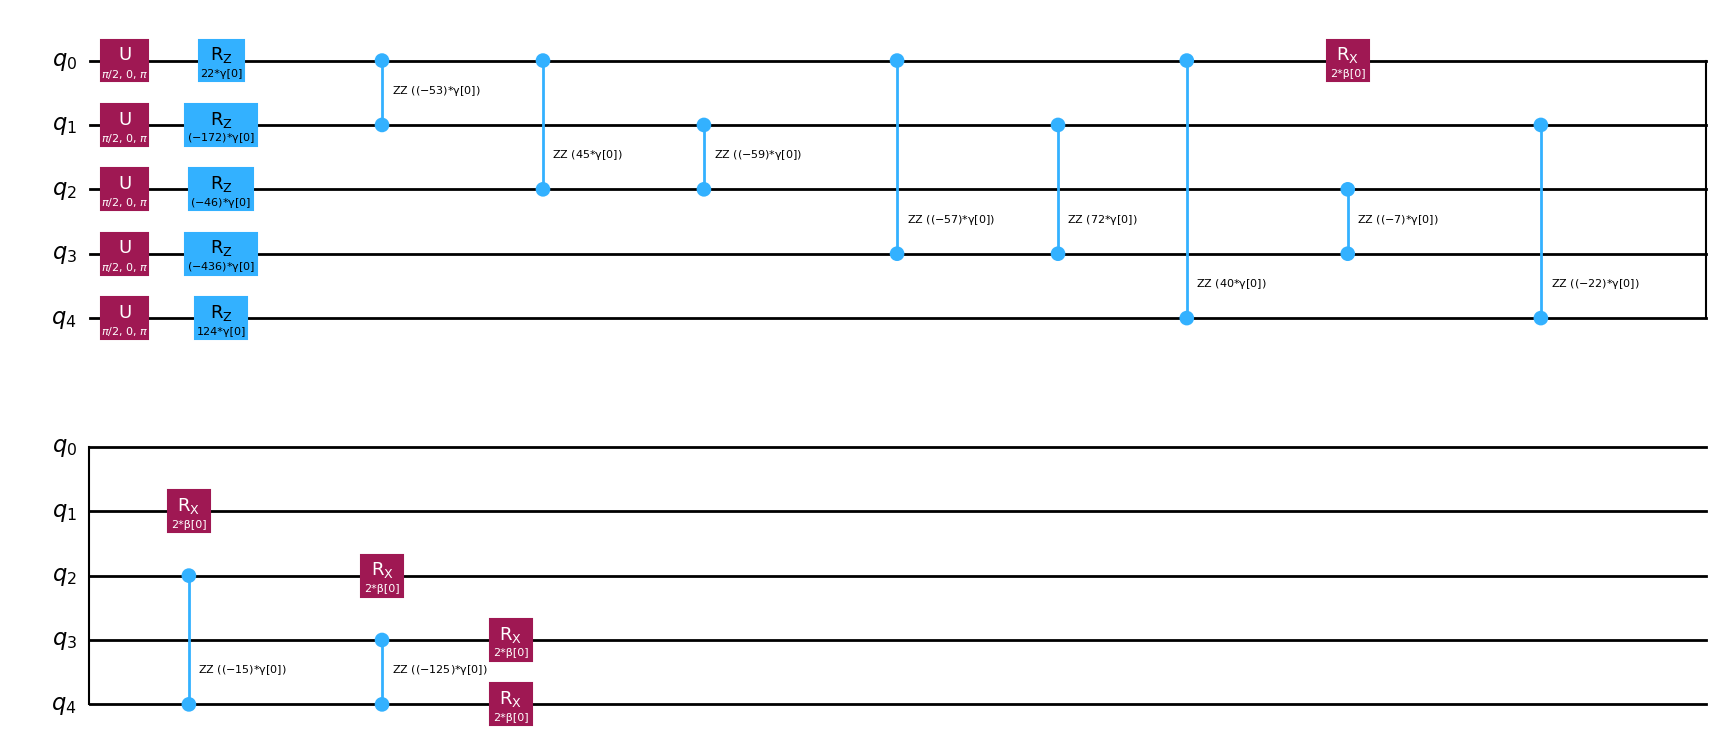

In [20]:
circuito = QAOAAnsatz(cost_operator = Hc, reps = 1)


print(circuito.decompose(reps = 2)) 

circuito.decompose(reps = 2).draw('mpl') #Muestro el circuito

#### Prueba de StatevectorEstimator()

In [21]:
circuito.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(γ[0])])

In [22]:
circuito_cop = circuito.copy()
circuito_cop.measure_all()

In [23]:
simulator = StatevectorEstimator()

x_prueba = np.random.uniform(0, 2*np.pi, circuito_cop.num_parameters)

job = simulator.run([(circuito, Hc, x_prueba)])
result = job.result()[0]

In [24]:
print(result.data.evs)

21.02814347400646


### Definición del Algoritmo de QAOA

In [25]:
def qaoa_algorithm(circuito, Hc, min_method = 'Nelder-Mead'):
    

    parameters = circuito.parameters
    #Obtengo parametros = ParameterView([Parameter(beta[]0),.., Parameter(alfa[0]),.., Parameter[alfa[n - 1]]])


    num_parameters = circuito.num_parameters

    def func_to_minimize(x):

        simulator = StatevectorEstimator() #Instancio el simulador exacto sin ruido

        job = simulator.run([(circuito, Hc, x)])
        result = job.result()[0]
        
        return result.data.evs
    

    x0 = np.asarray([0.0]*num_parameters) #Parametros iniciales

    result = minimize(func_to_minimize, x0, method = min_method)

    return {param: val for param, val in zip(parameters, result.x)}

In [26]:
opt_parameters_dict = qaoa_algorithm(circuito, Hc)

print(opt_parameters_dict)

ncircuito = circuito.assign_parameters(opt_parameters_dict) #Asigno los parametros

print(ncircuito.decompose(reps = 2)) #Muestro el circuito

{ParameterVectorElement(β[0]): np.float64(-0.6164770611892226), ParameterVectorElement(γ[0]): np.float64(0.0033044176020335424)}
     ┌────────────┐┌──────────────┐                                           »
q_0: ┤ U(π/2,0,π) ├┤ Rz(0.072697) ├─■──────────────■──────────────────────────»
     ├────────────┤├──────────────┤ │ZZ(-0.17513)  │                          »
q_1: ┤ U(π/2,0,π) ├┤ Rz(-0.56836) ├─■──────────────┼────────────■─────────────»
     ├────────────┤└┬────────────┬┘                │ZZ(0.1487)  │ZZ(-0.19496) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz(-0.152) ├─────────────────■────────────■─────────────»
     ├────────────┤┌┴────────────┤                                            »
q_3: ┤ U(π/2,0,π) ├┤ Rz(-1.4407) ├────────────────────────────────────────────»
     ├────────────┤├─────────────┤                                            »
q_4: ┤ U(π/2,0,π) ├┤ Rz(0.40975) ├────────────────────────────────────────────»
     └────────────┘└─────────────┘                                     

In [42]:
def samples_from_parameters (circuit, opt_parameters, Hc, shots):

    sampler = StatevectorSampler() #Declaro un Sampler exacto

    circWithParam = circuit.assign_parameters(opt_parameters)

    circWithParam.measure_all()

    
    job = sampler.run([(circWithParam, None)], shots = shots)
    
    result = job.result()[0] 

    counts = result.data.meas.get_counts() #Obtengo un diccionario [bitstring : frecuencia]

    ordered_counts = dict(sorted(counts.items(), key = lambda x: x[1], reverse = True))

    return ordered_counts

In [51]:
results = samples_from_parameters(circuito, opt_parameters_dict, Hc, shots = 10_000)

In [52]:
print(len(results))
for bitstring, c in results.items():
    print(f"Bistring: {bitstring} -> Counts: {c}")

31
Bistring: 10001 -> Counts: 1256
Bistring: 10000 -> Counts: 1210
Bistring: 10100 -> Counts: 1048
Bistring: 00001 -> Counts: 832
Bistring: 10101 -> Counts: 802
Bistring: 00000 -> Counts: 635
Bistring: 10111 -> Counts: 458
Bistring: 00101 -> Counts: 449
Bistring: 10011 -> Counts: 409
Bistring: 00100 -> Counts: 406
Bistring: 10110 -> Counts: 391
Bistring: 11001 -> Counts: 328
Bistring: 10010 -> Counts: 281
Bistring: 00011 -> Counts: 279
Bistring: 00111 -> Counts: 223
Bistring: 00110 -> Counts: 205
Bistring: 11101 -> Counts: 202
Bistring: 00010 -> Counts: 187
Bistring: 11100 -> Counts: 112
Bistring: 11000 -> Counts: 96
Bistring: 01010 -> Counts: 38
Bistring: 11111 -> Counts: 35
Bistring: 01110 -> Counts: 32
Bistring: 01000 -> Counts: 25
Bistring: 01011 -> Counts: 16
Bistring: 11011 -> Counts: 12
Bistring: 01100 -> Counts: 12
Bistring: 01111 -> Counts: 9
Bistring: 01101 -> Counts: 7
Bistring: 11010 -> Counts: 3
Bistring: 01001 -> Counts: 2


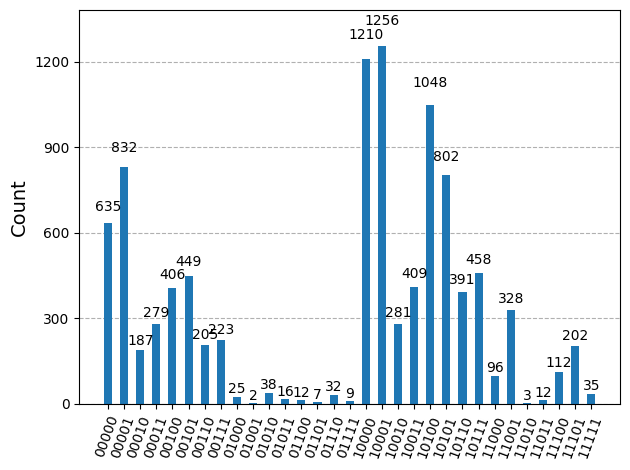

In [53]:
plot_histogram(results)

### Obtener Pares SR

In [108]:
def bitstring2vector(bitstrings):

    return np.array([[int(c) for c in bstring] for bstring in bitstrings])


def bitstring2latticeVectors(D, state_bistring, step_signs, b_op): 

    bits = bitstring2vector(state_bistring) #Obtengo el vector de bits de la cadena

    aux = np.multiply(step_signs, bits)

    movement = aux @ D # (n_states, n_bits) @ (n_bits, n_dim)
    

    vnew = b_op + movement

    return vnew

In [109]:
vnew = bitstring2latticeVectors(D, results.keys(), step_signs, b_op)
print(vnew)

[[    13.      0.      0.      2.      4. 176979.]
 [    -1.      3.      4.      6.      2. 176976.]
 [    -3.      9.      8.     -1.     10. 176977.]
 [     8.     -3.     -4.      6.      4. 176986.]
 [    11.      6.      4.     -5.     12. 176980.]
 [    -6.      0.      0.     10.      2. 176983.]
 [     1.      6.     -6.     -1.     18. 176973.]
 [     6.      3.      0.     -1.     12. 176987.]
 [     3.      0.    -10.      6.     10. 176972.]
 [    -8.      6.      4.      3.     10. 176984.]
 [   -13.      9.     -2.      3.     16. 176970.]
 [    12.      6.     -8.      7.      0. 176981.]
 [   -11.      3.     -6.     10.      8. 176969.]
 [    -2.     -3.    -14.     10.     10. 176979.]
 [    -4.      3.    -10.      3.     18. 176980.]
 [   -18.      6.     -6.      7.     16. 176977.]
 [    10.     12.     -4.      0.      8. 176982.]
 [   -16.      0.    -10.     14.      8. 176976.]
 [    -4.     15.      0.      4.      6. 176979.]
 [    -2.      9.     -4.     1

In [ ]:
def is_smooth(u, smooth_bound): # Comprobar si es n_smooth
    base = primes[: smooth_bound]
    
    for p in base:
        while u % p == 0:
            u = u/p
    
    return u == 1


def vectors_to_u_v_smooth_pairs(vectors):
    

    return 0